In [73]:
import pandas as pd
from scipy.special import style

In [74]:
df1 = pd.read_csv('main_result.csv')
df1 = df1[df1['n_self_alignment'] == 5]

# get the min and max values for each target_character
target_characters = df1['target_character'].unique()

min_max_values = {}
for char in target_characters:
    char_df = df1[df1['target_character'] == char]
    min_score = char_df['score'].min()
    max_score = char_df['score'].max()
    min_max_values[char] = (min_score, max_score)
   

In [75]:
df2 = pd.read_csv('feedback_result.csv')
df = pd.concat([df1, df2], axis=0)
df = df[df['gpt_model'] == 'gpt-4o']
df

,run_id,final_state,target_character,pe,gpt_model,branch_factor,exp_name,evaluator,total_iterations,n_self_alignment,...,Evaluation/reach_imp_perc,Evaluation/path_length,Evaluation/fn_imp_perc,Evaluation/fp_imp_perc,Evaluation/tn_imp_perc,Evaluation/tp_imp_perc,Evaluation/solvability,Evaluation/playability,score,Evaluation/naive_playability
168,3kk20v1f,finished,1,cot,gpt-4o,2,sa,hr,6,5,...,0.666667,27.846155,2.500000,0.4,0.000000,0.100000,0.200000,0.433333,0.033333,NaN
169,3kk20v1f,finished,1,cot,gpt-4o,2,sa,hr,6,5,...,0.233333,0.000000,3.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
170,3kk20v1f,finished,1,cot,gpt-4o,2,sa,hr,6,5,...,0.433333,26.750000,2.733334,0.0,0.200000,0.066667,0.100000,0.266667,0.088889,NaN
171,3kk20v1f,finished,1,cot,gpt-4o,2,sa,hr,6,5,...,0.366667,26.285715,2.833333,0.0,0.133333,0.033333,0.066667,0.233333,0.055556,NaN
172,3kk20v1f,finished,1,cot,gpt-4o,2,sa,hr,6,5,...,0.700000,26.700001,1.800000,0.0,0.866667,0.333333,0.433333,0.666667,0.400000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,szkn8zgd,finished,6,tot,gpt-4o,2,feedback,hr,6,5,...,NaN,NaN,NaN,NaN,NaN,NaN,0.633333,0.000000,0.000000,0.633333
716,szkn8zgd,finished,6,tot,gpt-4o,2,feedback,hr,6,5,...,NaN,NaN,NaN,NaN,NaN,NaN,0.700000,0.000000,0.000000,0.700000
717,szkn8zgd,finished,6,tot,gpt-4o,2,feedback,hr,6,5,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,1.000000
718,szkn8zgd,finished,6,tot,gpt-4o,2,feedback,hr,6,5,...,NaN,NaN,NaN,NaN,NaN,NaN,0.633333,0.000000,0.000000,0.633333


In [76]:
# min-max normalization with 'score' column for target_character-wise
def min_max_normalize(df):
    df = df.copy()
    
    # normalize within each target_character group (pre-computed min-max)
    def normalize_row(row):
        min_score, max_score = min_max_values[row['target_character']]
        if max_score - min_score == 0:
            return 0.0  # avoid division by zero
        return (row['score'] - min_score) / (max_score - min_score)
    
    df['score'] = df.apply(normalize_row, axis=1)
    return df

df = min_max_normalize(df)
df

,run_id,final_state,target_character,pe,gpt_model,branch_factor,exp_name,evaluator,total_iterations,n_self_alignment,...,Evaluation/reach_imp_perc,Evaluation/path_length,Evaluation/fn_imp_perc,Evaluation/fp_imp_perc,Evaluation/tn_imp_perc,Evaluation/tp_imp_perc,Evaluation/solvability,Evaluation/playability,score,Evaluation/naive_playability
168,3kk20v1f,finished,1,cot,gpt-4o,2,sa,hr,6,5,...,0.666667,27.846155,2.500000,0.4,0.000000,0.100000,0.200000,0.433333,0.042857,NaN
169,3kk20v1f,finished,1,cot,gpt-4o,2,sa,hr,6,5,...,0.233333,0.000000,3.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
170,3kk20v1f,finished,1,cot,gpt-4o,2,sa,hr,6,5,...,0.433333,26.750000,2.733334,0.0,0.200000,0.066667,0.100000,0.266667,0.114286,NaN
171,3kk20v1f,finished,1,cot,gpt-4o,2,sa,hr,6,5,...,0.366667,26.285715,2.833333,0.0,0.133333,0.033333,0.066667,0.233333,0.071429,NaN
172,3kk20v1f,finished,1,cot,gpt-4o,2,sa,hr,6,5,...,0.700000,26.700001,1.800000,0.0,0.866667,0.333333,0.433333,0.666667,0.514286,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,szkn8zgd,finished,6,tot,gpt-4o,2,feedback,hr,6,5,...,NaN,NaN,NaN,NaN,NaN,NaN,0.633333,0.000000,0.000000,0.633333
716,szkn8zgd,finished,6,tot,gpt-4o,2,feedback,hr,6,5,...,NaN,NaN,NaN,NaN,NaN,NaN,0.700000,0.000000,0.000000,0.700000
717,szkn8zgd,finished,6,tot,gpt-4o,2,feedback,hr,6,5,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,1.000000
718,szkn8zgd,finished,6,tot,gpt-4o,2,feedback,hr,6,5,...,NaN,NaN,NaN,NaN,NaN,NaN,0.633333,0.000000,0.000000,0.633333


In [77]:
# replace feedback_type no -> No, generic -> Generic, default -> Specific
df['feedback_type'] = df['feedback_type'].replace({'no': 'no', 'generic': 'generic', 'default': 'specific'})

In [78]:
df.groupby(['pe', 'target_character', 'feedback_type']).agg({'Evaluation/llm_iteration': ['count']})

Evaluation/llm_iteration
                                                      count
pe  target_character feedback_type                         
cot 1                generic                             30
                     no                                  30
                     specific                            30
    2                generic                             30
                     no                                  30
                     specific                            30
    5                generic                             30
                     no                                  30
                     specific                            30
    6                generic                             30
                     no                                  30
                     specific                            30
got 1                generic                             30
                     no                                  30
                     specific                            30
    2                generic                             30
                     no                                  30
                     specific                            30
    5                generic                             30
                     no                                  30
                     specific                            30
    6                generic                             30
                     no                                  30
                     specific                            30
tot 1                generic                             30
                     no                                  30
                     specific                            30
    2                generic                             30
                     no                                  30
                     specific                            30
    5                generic                             30
                     no                                  30
                     specific                            30
    6                generic                             30
                     no                                  30
                     specific                            30

In [79]:
# min-max normalization with 'score' column for target_character-wise
def min_max_normalize(df):
    df = df.copy()
    def normalize_group(sub_df):
        min_val = sub_df['score'].min()
        max_val = sub_df['score'].max()
        if max_val > min_val:
            sub_df['score'] = (sub_df['score'] - min_val) / (max_val - min_val)
        else:
            sub_df['score'] = 0.0  # 모든 값이 동일한 경우
        return sub_df
    return df.groupby('target_character').apply(normalize_group).reset_index(drop=True)
normalized = min_max_normalize(df)

/var/folders/x_/2lt9k5kn52q43m1_z0kp7tfm0000gn/T/ipykernel_93037/1372647707.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('target_character').apply(normalize_group).reset_index(drop=True)


In [80]:
# normalized = pd.concat([normalized, mean_df], ignore_index=True)
normalized = pd.concat([normalized], ignore_index=True)
normalized['pe'].unique()
len(normalized)

1080

In [81]:

run_ids = normalized['run_id'].unique()
len(run_ids)


imp_rows = list()

for run_id in run_ids:
    
    for iter in range(2, 7):
        curr_row = normalized[(normalized['run_id'] == run_id) & (normalized['Evaluation/llm_iteration'] == iter)]
        prev_row = normalized[(normalized['run_id'] == run_id) & (normalized['Evaluation/llm_iteration'] == iter - 1)]
        
        imp_score = curr_row['score'].values[0] - prev_row['score'].values[0]
        
        imp_rows.append(
            {
                'run_id': run_id,
                'Evaluation/llm_iteration': iter,
                'delta_score': imp_score,
                'pe': curr_row['pe'].values[0],
                'feedback_type': curr_row['feedback_type'].values[0],
                'seed': curr_row['seed'].values[0],
            }
        )

imp_df = pd.DataFrame(imp_rows)
imp_df

,run_id,Evaluation/llm_iteration,delta_score,pe,feedback_type,seed
0,3kk20v1f,2,-0.042857,cot,specific,3
1,3kk20v1f,3,0.114286,cot,specific,3
2,3kk20v1f,4,-0.042857,cot,specific,3
3,3kk20v1f,5,0.442857,cot,specific,3
4,3kk20v1f,6,0.028571,cot,specific,3
...,...,...,...,...,...,...
895,szkn8zgd,2,0.000000,tot,no,10
896,szkn8zgd,3,0.000000,tot,no,10
897,szkn8zgd,4,0.000000,tot,no,10
898,szkn8zgd,5,0.000000,tot,no,10


imp_df = imp_df.groupby(['pe', 'Evaluation/llm_iteration', 'feedback_type']).agg({'delta_score': 'mean'}).reset_index()
imp_df

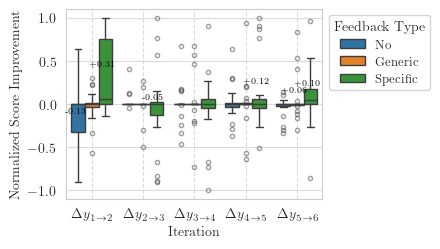

In [170]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['text.usetex'] = True
plt.rc('font', family='Times New Roman')  # Windows의 경우


df_plot = imp_df[imp_df['pe'] == 'got'].copy()

plt.figure(figsize=(4.5, 2.6))

iteration_labels = {
    0: r'$\Delta y_{1\rightarrow{}2}$',
    1: r'$\Delta y_{2\rightarrow{}3}$',
    2: r'$\Delta y_{3\rightarrow{}4}$',
    3: r'$\Delta y_{4\rightarrow{}5}$',
    4: r'$\Delta y_{5\rightarrow{}6}$',
}

df_plot['feedback_type'] = df_plot['feedback_type'].replace({
    'no': 'No',
    'generic': 'Generic',
    'specific': 'Specific'
})

# === 평균값 계산 ===
group_means = df_plot.groupby(
    ['Evaluation/llm_iteration', 'feedback_type']
)['delta_score'].mean().reset_index()

df_plot['feedback_type'] = pd.Categorical(
    df_plot['feedback_type'], 
    categories=['No', 'Generic', 'Specific'], 
    ordered=True
)

ax = sns.boxplot(
    data=df_plot, 
    x='Evaluation/llm_iteration', 
    y='delta_score', 
    hue='feedback_type',
    whis=2.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.5)  # 점 작게/투명
)


# --- 색상 팔레트 ---
palette = {
    'No': '#1f77b4',       # 파랑
    'Generic': '#ff7f0e',  # 주황
    'Specific': '#2ca02c'  # 초록
}

# === 평균값 텍스트 표시 ===
for i, iteration in enumerate(range(2, 7)):
    for j, feedback in enumerate(['No', 'Generic', 'Specific']):
        mean_val = group_means[
            (group_means['Evaluation/llm_iteration'] == iteration) & 
            (group_means['feedback_type'] == feedback)
        ]['delta_score']

        if not mean_val.empty and abs(mean_val.values[0]) > 0.05:  # 평균값이 존재하고 0.01보다 큰 경우에만 표시            
            # hue offset (박스 3개가 좌우로 벌어지므로 -0.25, 0, +0.25 정도 보정)
            
            if abs(mean_val.values[0]) > 0.0:
                color = 'black'
            else:
                color = 'black'
            
            pos_neg = '+' if mean_val.values[0] > 0 else ''
            
            x_pos = (i) - 0.3 + (j) * 0.25
            ax.text(
                x_pos, mean_val.values[0] + j*0.05,
                f"{pos_neg}{mean_val.values[0]:.2f}",
                ha='center', va='bottom', fontsize=6, color=color, fontweight="bold"
            )

# === X축 tick label 교체 ===
ax.set_xticks(sorted(iteration_labels.keys()))
ax.set_xticklabels([iteration_labels[i] for i in sorted(iteration_labels.keys())])

plt.xlabel('Iteration')
plt.ylabel('Normalized Score Improvement')
plt.legend(title='Feedback Type', loc='upper left', bbox_to_anchor=(1, 1), fontsize=9)
plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('feedback_fig.pdf', dpi=300)
plt.show()
